In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import numpy as np
import matplotlib.pyplot as plt


In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0  # Normalize pixel values
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

def create_model(filter_size=3, regularization=0.001, optimizer='adam'):
    model = keras.Sequential([
        layers.Conv2D(32, (filter_size, filter_size), activation='relu', kernel_regularizer=regularizers.l2(regularization), input_shape=(28, 28, 1)),
        layers.MaxPooling2D(2, 2),
        layers.Conv2D(64, (filter_size, filter_size), activation='relu'),
        layers.MaxPooling2D(2, 2),
        layers.Flatten(),
        layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(regularization)),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [4]:
filter_sizes = [3, 5]
regularization_values = [0.001, 0.01]
batch_sizes = [32, 64]
optimizers = ['adam', 'sgd']

results = {}

In [6]:
for filter_size in filter_sizes:
    for reg in regularization_values:
        for batch_size in batch_sizes:
            for optimizer in optimizers:
                print(f"Training model with filter_size={filter_size}, reg={reg}, batch_size={batch_size}, optimizer={optimizer}")
                model = create_model(filter_size, reg, optimizer)
                history = model.fit(x_train, y_train, epochs=10, batch_size=batch_size, validation_data=(x_test, y_test), verbose=1)
                test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
                results[(filter_size, reg, batch_size, optimizer)] = (history, test_acc)

Training model with filter_size=3, reg=0.001, batch_size=32, optimizer=adam
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.7730 - loss: 0.7537 - val_accuracy: 0.8629 - val_loss: 0.4551
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8766 - loss: 0.4112 - val_accuracy: 0.8649 - val_loss: 0.4218
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8878 - loss: 0.3770 - val_accuracy: 0.8822 - val_loss: 0.3879
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8940 - loss: 0.3511 - val_accuracy: 0.8854 - val_loss: 0.3794
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9024 - loss: 0.3308 - val_accuracy: 0.8995 - val_loss: 0.3433
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9068 - loss: 0.3178 - val_accuracy: 0.8930 - val_loss: 0.3586
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9120 - loss: 0.3068 - val_accuracy: 0.8999 - val_loss: 0.3377
Epoch 8

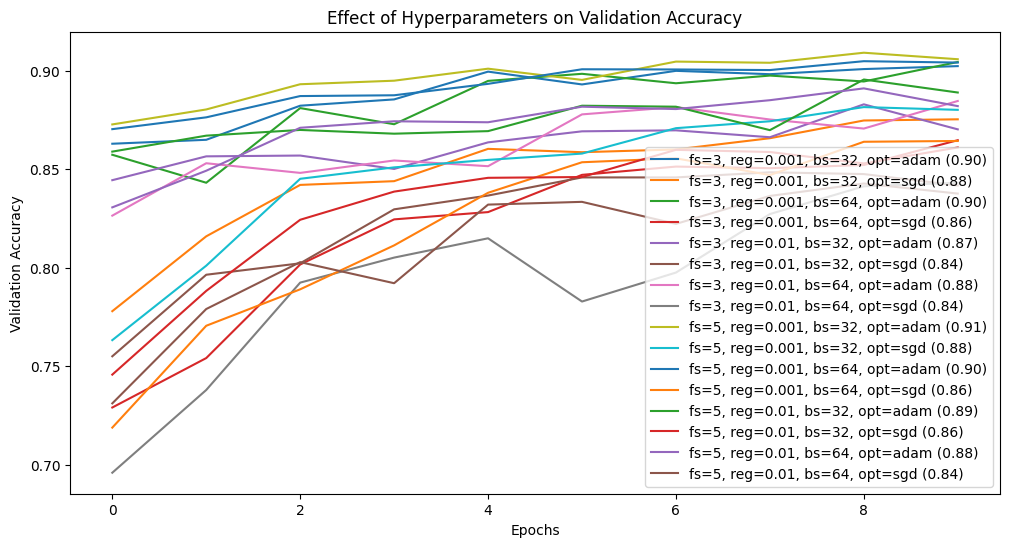

In [7]:
plt.figure(figsize=(12, 6))
for key, (history, acc) in results.items():
    filter_size, reg, batch_size, optimizer = key
    plt.plot(history.history['val_accuracy'], label=f'fs={filter_size}, reg={reg}, bs={batch_size}, opt={optimizer} ({acc:.2f})')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.title('Effect of Hyperparameters on Validation Accuracy')
plt.show()